# APL case study: treatment-resistant acute promyelocytic leukemia

This notebook reproduces and extends the APL case-study analyses used in the scBOLT draft. It is designed as a readable companion to the paper: each section introduces the biological question, then shows the code used to generate the corresponding exploratory or figure panel.

The analysis follows the scBOLT workflow from integrated single-cell transcriptomes to macrostate-level Boolean abstractions. The Boolean-network section is kept at the end, after the transcriptomic and binarisation evidence used to define model constraints.

## Table of contents

1. [Data and annotation](#data)
2. [Cell potency analysis](#potency)
3. [Macrostate characterisation](#macrostates)
4. [Macrostate binarisation](#binarisation)
5. [Functional binarisation diagnostics](#diagnostics)
6. [Boolean networks](#bn)


## Data and annotation <a class="anchor" id="data"></a>

The APL dataset contains control and retinoic-acid-treated PLZF-RARα mouse bone marrow cells. The integrated object is used to inspect shared and condition-specific transcriptional structure, while the condition-specific objects are used for macrostate-level analyses.


### Imports and plotting defaults

The notebook assumes the `scbolt-analysis` environment, which provides `scanpy`, `anndata`, `bonesistools`, GOATOOLS, and the plotting stack used below. Paths are defined once in the setup cell so that data inputs and exported figures are easy to audit.


In [48]:
%matplotlib inline

import warnings
from itertools import cycle
from pathlib import Path

import anndata as ad
import bonesistools as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("future.no_silent_downcasting", True)
bt.sct.pl.set_default_params()

DATA_DIR = Path("data/apl")
GO_DIR = Path("data/public/go")
FIGURE_DIR = Path(".")

plt.rcParams["xtick.labelsize"] = 14
plt.rcParams["ytick.labelsize"] = 14
plt.rcParams["legend.fontsize"] = 14

# Keep a stable biological ordering across all plots.
labels_order = ["Prom1", "Prom2", "Rep", "Cycl", "Neu", "Alt"]
colors = dict(zip(labels_order, cycle(bt.sct.pl.COLORS)))


In [49]:
def display_counts(counts, index_name="item", count_name="n"):
    """
    Display named counts as a compact notebook table.

    Parameters
    ----------
    counts: dict
        Mapping from item names to count values.
    index_name: str (default: "item")
        Name assigned to the index column.
    count_name: str (default: "n")
        Name assigned to the count column.

    Returns
    -------
    DataFrame
        Displayed count summary.
    """

    summary = pd.DataFrame(
        [(name, count) for name, count in counts.items()],
        columns=[index_name, count_name],
    )
    display(summary.style.hide(axis="index"))
    return summary


def display_matrix_preview(matrix, *, name, n_rows=5, n_cols=8):
    """
    Display a compact matrix preview.

    Parameters
    ----------
    matrix: DataFrame
        Matrix to summarise.
    name: str
        Label describing the previewed matrix.
    n_rows: int (default: 5)
        Number of rows to show in the preview.
    n_cols: int (default: 8)
        Number of columns to show in the preview.

    Returns
    -------
    DataFrame
        Matrix preview.
    """

    preview = matrix.iloc[:n_rows, :n_cols]
    display(preview)
    return preview


def layer_values(adata, gene, layer):
    """
    Return one gene expression vector from an AnnData layer as a Series.

    Parameters
    ----------
    adata: AnnData
        Annotated data matrix.
    gene: str
        Gene name to extract.
    layer: str
        Layer key containing expression values.

    Returns
    -------
    Series
        Expression values indexed by cell barcode.
    """

    values = adata[:, gene].layers[layer]
    if hasattr(values, "toarray"):
        values = values.toarray()
    return pd.Series(np.asarray(values).squeeze(), index=adata.obs.index, name=gene)


### Figure index <a class="anchor" id="figure-index"></a>

The notebook exports the following panels. Links jump to the section where each figure is created.

| Output file | Notebook section |
|---|---|
| `umap_conditions.pdf` | [Integrated UMAP by condition](#fig-umap-condition) |
| `umap_labels.pdf` | [Integrated UMAP by annotation](#fig-umap-label) |
| `boxplot_cytotrace_score.pdf` | [CytoTRACE potency panel](#fig-potency) |
| `umap_macrostates.pdf` | [KNNbs macrostates](#fig-macrostates) |
| `markers_extended.pdf` | [Extended GO marker diagnostics](#fig-markers-extended) |
| `markers.pdf` | [Paper-focused GO marker panel](#fig-markers-paper) |


### Load processed objects

The integrated object contains the shared embedding and manual cell annotations used for Figure 2a-b. The condition-specific objects keep the KNNbs macrostate labels used later for macrostate visualisation and binarisation.


In [40]:
adata = ad.read_h5ad(DATA_DIR / "integrated.h5ad")
adata.obs["label"] = adata.obs["label"].cat.reorder_categories(
    labels_order,
    ordered=True,
)
adata.obs["condition"] = adata.obs["condition"].cat.reorder_categories(
    ["ctrl", "treated"],
    ordered=True,
)
display(adata)


AnnData object with n_obs × n_vars = 12102 × 12918
    obs: 'G1_score', 'S_score', 'G2M_score', 'pypairs_max_class', 'pypairs_cc_prediction', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rps', 'pct_counts_rps', 'condition', 'leiden', 'label'
    var: 'Accession', 'symbol', 'mt', 'rps', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'ambiguous', 'correct', 'counts', 'log-norm', 'matrix', 'norm', 'scale', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [22]:
adata_ctrl = ad.read_h5ad(DATA_DIR / "ctrl.h5ad")
adata_ctrl.obs["macrostate"] = adata_ctrl.obs["macrostate"].cat.reorder_categories(
    labels_order,
    ordered=True,
)
display(adata_ctrl)

adata_treated = ad.read_h5ad(DATA_DIR / "treated.h5ad")
adata_treated.obs["macrostate"] = adata_treated.obs["macrostate"].cat.reorder_categories(
    labels_order,
    ordered=True,
)
display(adata_treated)


AnnData object with n_obs × n_vars = 5300 × 14094
    obs: 'G1_score', 'S_score', 'G2M_score', 'pypairs_max_class', 'pypairs_cc_prediction', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rps', 'pct_counts_rps', 'leiden', 'label', 'macrostate'
    var: 'Accession', 'symbol', 'mt', 'rps', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'shared_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'ambiguous', 'correct', 'counts', 'log-norm', 'matrix', 'norm', 'scale', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances', 'shared_neighbors_connectivities', 'shared_neighbors_distances'

AnnData object with n_obs × n_vars = 6802 × 13200
    obs: 'G1_score', 'S_score', 'G2M_score', 'pypairs_max_class', 'pypairs_cc_prediction', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rps', 'pct_counts_rps', 'leiden', 'label', 'macrostate'
    var: 'Accession', 'symbol', 'mt', 'rps', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'shared_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'ambiguous', 'correct', 'counts', 'log-norm', 'matrix', 'norm', 'scale', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances', 'shared_neighbors_connectivities', 'shared_neighbors_distances'

In [41]:
hvg_mask = sc.pp.highly_variable_genes(
    adata,
    layer="log-norm",
    flavor="cell_ranger",
    n_bins=20,
    batch_key="condition",
    inplace=False,
)["highly_variable"]
hvgs = list(hvg_mask[hvg_mask].index)
hvg_summary = display_counts(
    {"highly variable genes": len(hvgs)},
    index_name="selection",
    count_name="n_genes",
)

,selection,n_genes
0,highly variable genes,3082


### Integrated transcriptome overview <a class="anchor" id="fig-umap-condition"></a>

These UMAP panels reproduce the first visual checks of the case study: condition overlap highlights shared and condition-specific regions, while manual annotations define the biological populations used throughout the notebook.

<a class="anchor" id="fig-umap-label"></a>


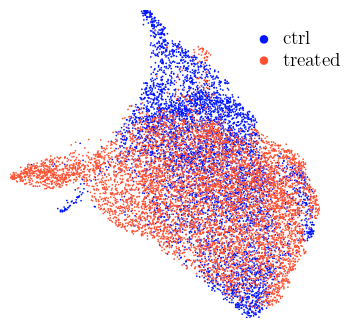

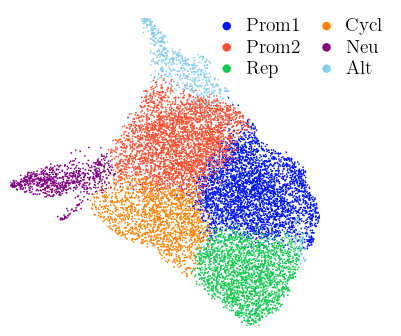

In [24]:
n_umap_components = 3 if adata.obsm["X_umap"].shape[1] > 2 else 2

bt.sct.pl.embedding_plot(
    adata,
    obs="condition",
    use_rep="X_umap",
    figheight=4,
    figwidth=5,
    xlabel=r"$\mathrm{UMAP_{1}}$",
    ylabel=r"$\mathrm{UMAP_{2}}$",
    zlabel=r"$\mathrm{UMAP_{3}}$",
    colors=bt.sct.pl.COLORS,
    s=1.5,
    alpha=1,
    add_labels=False,
    add_legend=True,
    lgd_params={
        "ncol": 1,
        "markerscale": 5,
        "frameon": False,
        "edgecolor": bt.sct.pl.get_color("black"),
        "shadow": False,
        "bbox_to_anchor": (0.7, 0.75),
        "columnspacing": 0.3,
        "handletextpad": 0,
        "labelspacing": 0.2,
        "fontsize": 14,
    },
    n_components=n_umap_components,
    background_visible=False,
)
plt.grid(False)
plt.axis(False)
plt.savefig(FIGURE_DIR / "umap_conditions.pdf")
plt.show()
plt.close()

bt.sct.pl.embedding_plot(
    adata,
    obs="label",
    use_rep="X_umap",
    figheight=4,
    figwidth=5,
    xlabel=r"$\mathrm{UMAP_{1}}$",
    ylabel=r"$\mathrm{UMAP_{2}}$",
    zlabel=r"$\mathrm{UMAP_{3}}$",
    colors=colors,
    s=1.5,
    alpha=1,
    add_labels=False,
    add_legend=True,
    n_components=n_umap_components,
    background_visible=False,
)
plt.legend(
    ncol=2,
    markerscale=5,
    frameon=False,
    edgecolor=bt.sct.pl.get_color("black"),
    shadow=False,
    bbox_to_anchor=(0.58, 0.75),
    columnspacing=0.3,
    handletextpad=0,
    labelspacing=0.2,
    fontsize=14,
)
plt.grid(False)
plt.axis(False)
plt.savefig(FIGURE_DIR / "umap_labels.pdf")
plt.show()
plt.close()


## Cell potency analysis <a class="anchor" id="potency"></a>

<a class="anchor" id="fig-potency"></a>

CytoTRACE potency scores are used here as a condition-independent proxy for developmental hierarchy. Lower scores correspond to more differentiated cells. In the APL draft, this analysis supports Prom1 as the least differentiated region and Neu/Alt as more terminal granulocyte-like states.


In [50]:
def generate_unique_index_name(dfs):
    """
    Generate an index column name that does not conflict with dataframe columns.

    Parameters
    ----------
    dfs: DataFrame or list of DataFrame
        Dataframe, or sequence of dataframes, whose column names are checked.

    Returns
    -------
    str
        Available column name. The default name is `"index"`; numbered suffixes
        are added until the name is unique.
    """

    dfs = [dfs] if isinstance(dfs, pd.DataFrame) else dfs
    column_names = set()
    for df in dfs:
        column_names.update(set(df.columns))
    index_name = "index"
    _i = 0
    while index_name in column_names:
        index_name = f"index_{_i}"
        _i += 1
    return index_name


conditions = ["ctrl", "treated"]
label_column = "condition"
cytotrace_files = [DATA_DIR / "potency_ctrl.csv", DATA_DIR / "potency_treated.csv"]

cytotrace_dfs = dict()
for condition, file in zip(conditions, cytotrace_files):
    cytotrace_dfs[condition] = pd.read_csv(file, sep=",", index_col=0)
    cytotrace_dfs[condition][label_column] = condition
cytotrace_df = pd.concat(cytotrace_dfs.values(), axis=0)

adata_df = adata.obs.copy()
cols_to_remove = set(adata_df.columns) & set(cytotrace_df.columns) - {label_column}
if cols_to_remove:
    adata_df = adata_df.drop(cols_to_remove, axis=1)

index_name = generate_unique_index_name([cytotrace_df, adata_df])
cytotrace_df[index_name] = cytotrace_df.index
cytotrace_df.set_index([index_name, label_column], inplace=True)
adata_df[index_name] = adata_df.index
adata_df.set_index([index_name, label_column], inplace=True)
adata_df = adata_df.merge(
    right=cytotrace_df,
    how="left",
    left_index=True,
    right_index=True
)
adata_df.reset_index(
    level=(label_column,),
    inplace=True
)
adata_df.index.name = None
adata.obs = adata_df.copy(deep=True)

del cytotrace_df, cytotrace_dfs, adata_df


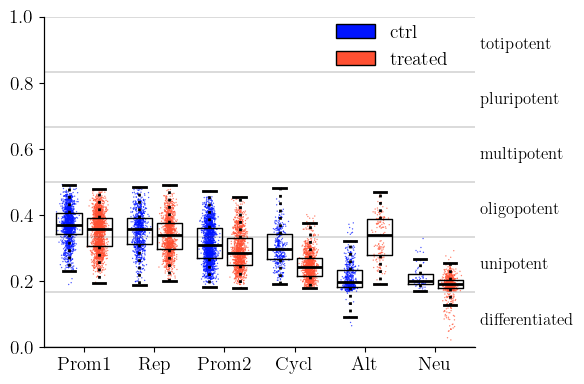

In [62]:
potency_ranges = np.linspace(0, 1, 7)
potency_labels = [
    "differentiated",
    "unipotent",
    "oligopotent",
    "multipotent",
    "pluripotent",
    "totipotent",
]

fig, ax, _ = bt.sct.pl.boxplot(
    adata,
    obs="score",
    groupby="label",
    hue="condition",
    sort="descending",
    showfliers=False,
    showpoints=True,
    legend_fontsize=12,
    figwidth=6,
    figheight=4,
)

legend = ax.get_legend()
if legend is not None:
    legend.set_title(None)
    legend.set_frame_on(False)
    legend.set_bbox_to_anchor((0.98, 1.03), transform=ax.transAxes)
    legend._loc = 1

ylim_min, ylim_max = 0, 1
plt.ylim((ylim_min, ylim_max))

potency_tick_positions = np.linspace(
    (ylim_max - ylim_min) / (2 * len(potency_labels)),
    1 - ((ylim_max - ylim_min) / (2 * len(potency_labels))),
    len(potency_labels),
)
twin_ax = ax.twinx()
twin_ax.set_yticks(potency_tick_positions)
twin_ax.set_yticklabels(potency_labels)
twin_ax.tick_params(axis="y", labelsize=12, length=0)

fig.tight_layout()
plt.hlines(
    y=potency_ranges,
    xmin=ax.get_xlim()[0],
    xmax=ax.get_xlim()[1],
    colors=bt.sct.pl.get_color("black"),
    linestyles="-",
    linewidth=0.2,
)
fig.tight_layout()
plt.show()
plt.close()


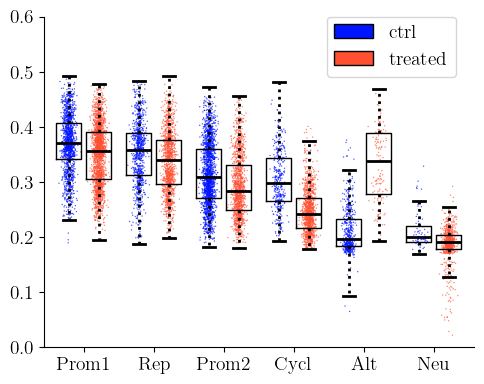

In [60]:
fig, ax, _ = bt.sct.pl.boxplot(
    adata,
    obs="score",
    groupby="label",
    hue="condition",
    sort="descending",
    showfliers=False,
    showpoints=True,
    figwidth=5,
    figheight=4,
)

legend = ax.get_legend()
if legend is not None:
    legend.set_bbox_to_anchor((0.98, 1.03), transform=ax.transAxes)
    legend._loc = 1

ylim_min, ylim_max = 0, 0.6
plt.ylim((ylim_min, ylim_max))
fig.tight_layout()
plt.savefig(FIGURE_DIR / "boxplot_cytotrace_score.pdf")
plt.show()
plt.close()


Potency distributions are plotted by manual annotation and condition. The first plot keeps the full 0-1 scale and overlays coarse potency classes; the exported panel focuses on the lower score range where most APL cells lie.

These trends are used downstream to motivate Prom1 as an initial state, Prom2 as an intermediate state, and Neu/Alt/Rep as candidate terminal behaviours.


## Macrostate characterisation <a class="anchor" id="macrostates"></a>


<a class="anchor" id="fig-macrostates"></a>

Macrostates provide the reduced state-space representation used by scBOLT. In this case study, they were inferred with KNNbs because velocity-based CellRank assumptions are fragile in highly proliferative APL, while the embedding has limited branching structure for STREAM-like approaches.

The condition-specific views below show the KNNbs macrostates used for binarisation and model specification.


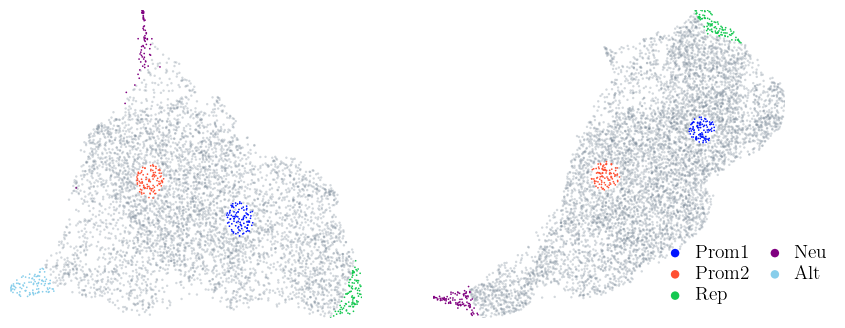

In [28]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

bt.sct.pl.embedding_plot(
    adata_ctrl,
    obs="macrostate",
    use_rep="X_umap",
    xlabel=r"$\mathrm{UMAP_{1}}$",
    ylabel=r"$\mathrm{UMAP_{2}}$",
    zlabel=r"$\mathrm{UMAP_{3}}$",
    colors=colors,
    s=1.5,
    alpha=1,
    add_labels=False,
    add_legend=False,
    n_components=3 if adata_ctrl.obsm["X_umap"].shape[1] > 2 else 2,
    background_visible=False,
    ax=axs[0],
)
axs[0].grid(False)
axs[0].axis(False)

bt.sct.pl.embedding_plot(
    adata_treated,
    obs="macrostate",
    use_rep="X_umap",
    xlabel=r"$\mathrm{UMAP_{1}}$",
    ylabel=r"$\mathrm{UMAP_{2}}$",
    zlabel=r"$\mathrm{UMAP_{3}}$",
    colors=colors,
    s=1.5,
    alpha=1,
    add_labels=False,
    add_legend=False,
    n_components=3 if adata_treated.obsm["X_umap"].shape[1] > 2 else 2,
    background_visible=False,
    ax=axs[1],
)
axs[1].grid(False)
axs[1].axis(False)

handles, labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    ncol=2,
    markerscale=5,
    frameon=False,
    edgecolor=bt.sct.pl.get_color("black"),
    shadow=False,
    columnspacing=0.3,
    handletextpad=0,
    labelspacing=0.2,
    fontsize=14,
    loc="lower right",
    bbox_to_anchor=(0.96, 0.1),
)
plt.savefig(FIGURE_DIR / "umap_macrostates.pdf")
plt.show()
plt.close()

## Macrostate binarisation <a class="anchor" id="binarisation"></a>

Each macrostate is represented as a partially defined Boolean vector over genes: `0` for inactive, `1` for active, and `*` for undefined. The HVG-restricted matrix is used for biological diagnostics and as a compact abstraction of condition- and macrostate-specific transcriptional programmes.

The full matrix is large, so the notebook displays a compact summary and a small HVG preview rather than dumping every gene column.


In [29]:
bin_macrostates = (
    pd.read_csv(DATA_DIR / "mstates_bin.csv", index_col=0)
    .fillna("*")
    .replace("-", "_")
)
bin_macrostates.index = pd.MultiIndex.from_tuples(
    tuple(name.split("_")) for name in bin_macrostates.index
)

bin_macrostates_hvg = bin_macrostates.loc[:, hvgs].copy()
background = list(bin_macrostates_hvg.columns)


In [63]:
binarisation_summary = display_counts(
    {
        "macrostates": bin_macrostates.shape[0],
        "total genes": bin_macrostates.shape[1],
        "highly variable genes": bin_macrostates_hvg.shape[1],
    },
    index_name="",
    count_name="value",
)

bin_macrostates_preview = display_matrix_preview(
    bin_macrostates_hvg,
    name="HVG binarisation matrix",
    n_rows=bin_macrostates_hvg.shape[0],
    n_cols=8,
)


,value
macrostates,9
total genes,12918
highly variable genes,3082


0610009L18Rik 0610030E20Rik 1110035H17Rik  1500009L16Rik  \
ctrl    Alt               *           0.0             *            0.0   
        Neu               *           0.0             *            0.0   
        Prom1             *             *           1.0            1.0   
        Prom2             *           0.0             *            1.0   
        Rep             0.0             *             *            1.0   
treated Neu               *           0.0             *            0.0   
        Prom1             *           1.0             *            0.0   
        Prom2             *             *             *            0.0   
        Rep               *             *             *            0.0   

              1500011B03Rik 1700006J14Rik 1700012B09Rik 1700037C18Rik  
ctrl    Alt               *             *             *             *  
        Neu               *             *             *             *  
        Prom1             *             *             *             *  
        Prom2             *             *           1.0             *  
        Rep               *             *             *             *  
treated Neu             0.0           0.0           0.0             *  
        Prom1             *             *             *             *  
        Prom2             *             *           0.0             *  
        Rep               *             *             *             *

### Marker-level validation of Neu and Alt

Before summarising whole GO-derived gene sets, it is useful to inspect canonical neutrophil markers directly. The `Cycl` cells are hidden here, and the rare treated `Alt` labels are removed, to keep the density comparison focused on the terminal-like macrostates.


In [31]:
truncated_labels = {
    "ctrl": adata_ctrl.obs["label"].copy(deep=True),
    "treated": adata_treated.obs["label"].copy(deep=True),
}
truncated_labels["ctrl"].loc[truncated_labels["ctrl"].isin(["Cycl"])] = np.nan
truncated_labels["treated"].loc[truncated_labels["treated"].isin(["Cycl", "Alt"])] = np.nan

adata_ctrl.obs["trunc_label"] = truncated_labels["ctrl"]
adata_treated.obs["trunc_label"] = truncated_labels["treated"]


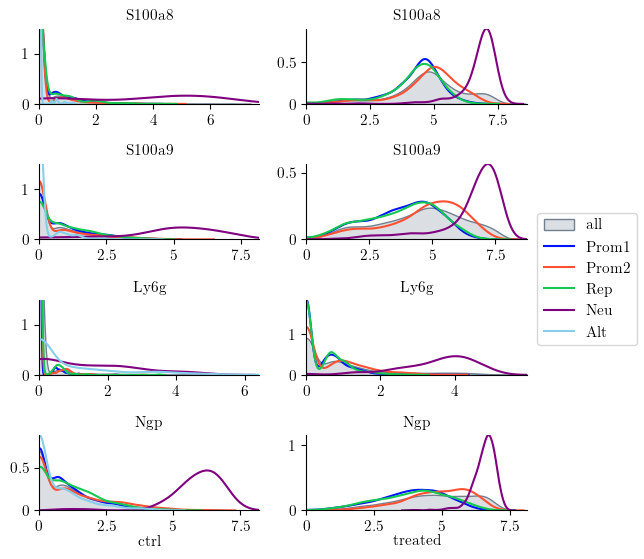

In [69]:
neutrophil_marker_genes = ["S100a8", "S100a9", "Ly6g", "Ngp"]

fig, axes = plt.subplots(
    len(neutrophil_marker_genes),
    2,
    figsize=(6.5, 1.4 * len(neutrophil_marker_genes)),
    sharex=False,
    sharey=False,
)

for i, gene in enumerate(neutrophil_marker_genes):
    bt.sct.pl.kde_plot(
        adata_ctrl,
        gene,
        layer="log-norm",
        obs="trunc_label",
        not_all=False,
        clip=False,
        colors=colors,
        show_legend=False,
        title=gene,
        xlabel=None,
        ylabel=None,
        ax=axes[i, 0],
    )
    axes[i, 0].title.set_fontsize(11)
    counts = layer_values(adata_ctrl, gene, layer="log-norm")
    axes[i, 0].set_xlim(min(counts), max(counts) * 1.1)

    bt.sct.pl.kde_plot(
        adata_treated,
        gene,
        layer="log-norm",
        obs="trunc_label",
        not_all=False,
        clip=False,
        colors=colors,
        show_legend=False,
        title=gene,
        xlabel=None,
        ylabel=None,
        ax=axes[i, 1],
    )
    axes[i, 1].title.set_fontsize(11)
    counts = layer_values(adata_treated, gene, layer="log-norm")
    axes[i, 1].set_xlim(min(counts), max(counts) * 1.1)

for ax in axes.ravel():
    ax.tick_params(axis="both", labelsize=11)

for ax in axes[:3, 0]:
    ax.set_ylim(0, 1.5)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", fontsize=11)
plt.tight_layout(rect=[0, 0, 0.85, 1])

pos_left = axes[0, 0].get_position()
pos_right = axes[0, 1].get_position()
x_left = pos_left.x0 + pos_left.width / 2
x_right = pos_right.x0 + pos_right.width / 2
fig.text(x_left, 0.01, "ctrl", ha="center", fontsize=11)
fig.text(x_right, 0.01, "treated", ha="center", fontsize=11)

plt.show()
plt.close()


The density plots focus on canonical neutrophil markers (`S100a8`, `S100a9`, `Ly6g`, `Ngp`). They provide a direct expression-level check that the Neu macrostate captures a mature neutrophil-like programme, while helping distinguish it from the altered Alt state.


## Functional binarisation diagnostics <a class="anchor" id="diagnostics"></a>

The next cells compare binarised values for GO-derived gene sets across terminal macrostates. This is a sanity check rather than a new inference step: proliferative macrostates should activate proliferation-associated processes, while Neu and Alt should differ in neutrophil, inflammatory, and stress-related programmes.


In [33]:
from collections import deque

from goatools.obo_parser import GODag


def get_go_children(go_id, go_dag, depth=None):
    """
    Collect descendant GO terms from a GO DAG term.

    Parameters
    ----------
    go_id: str
        Parent GO identifier.
    go_dag: GODag
        Gene Ontology directed acyclic graph, as loaded by GOATOOLS.
    depth: int, optional
        Maximum descendant depth. If None, collect all descendants.

    Returns
    -------
    set
        GO identifiers for descendant terms.
    """

    children = set()
    queue = deque([(go_id, 0)])

    while queue:
        term, d = queue.popleft()

        if depth is not None and d >= depth:
            continue

        for child in go_dag[term].children:
            child_id = child.item_id
            if child_id not in children:
                children.add(child_id)
                queue.append((child_id, d + 1))

    return children


def get_genes_from_go(go, go2gene, go_dag, depth=None):
    """
    Retrieve background genes annotated to GO terms and their descendants.

    Parameters
    ----------
    go: str or list or set or tuple
        GO identifier, or collection of GO identifiers, used as query roots.
    go2gene: dict
        Mapping from GO identifiers to gene names.
    go_dag: GODag
        Gene Ontology directed acyclic graph, as loaded by GOATOOLS.
    depth: int, optional
        Maximum descendant depth. If 0, only use the query terms. If None,
        include all descendant terms.

    Returns
    -------
    set
        Genes annotated to the selected GO terms and present in `go2gene`.
    """

    genes = set()

    go_terms = set(go) if isinstance(go, (list, set, tuple)) else {go}

    expanded_terms = set()
    for term in go_terms:
        if term in go_dag:
            expanded_terms.add(term)
            expanded_terms.update(get_go_children(term, go_dag, depth=depth))

    for term in expanded_terms:
        genes.update(go2gene.get(term, set()))

    return genes


genesyn = bt.dbs.ncbi.GeneSynonyms(organism="mouse")

go_dag = GODag(str(GO_DIR / "go_basic.obo"))
gene2go = pd.read_csv(GO_DIR / "gene2go", sep="\t")
gene2go = gene2go[gene2go["#tax_id"] == 10090]
gene2go["gene"] = genesyn(
    list(gene2go["GeneID"].astype(str)),
    input_identifier_type="gene_id",
    output_identifier_type="official_name",
)
gene2go = gene2go.loc[gene2go["gene"].isin(background)]

go2gene = (
    gene2go.groupby("GO_ID")["gene"]
    .apply(lambda x: list(set(x)))
    .to_dict()
)


data/public/go/go_basic.obo: fmt(1.2) rel(2026-03-25) 41,853 Terms


In [93]:
def plot_marker_binarisation_panel(
    df,
    genes,
    groups=None,
    colors=None,
    ax=None,
):
    """
    Draw stacked bars for partially binarised gene values.

    Parameters
    ----------
    df: DataFrame
        Partially binarised matrix with macrostates in rows and genes in
        columns. Values are expected to be 0, 1, or NaN.
    genes: list
        Genes used to normalise stacked bar heights.
    groups: list, optional
        Row labels, or MultiIndex keys, to plot. If None, use all rows in
        `df.index`.
    colors: list, optional
        Colors used for values 0, NaN, and 1, respectively.
    ax: Axes, optional
        Matplotlib axes on which to draw the bars.
    """

    if groups is None:
        groups = list(df.index)
    if colors is None:
        colors = [
            bt.sct.pl.get_color("darkred"),
            bt.sct.pl.get_color("lightgray"),
            bt.sct.pl.get_color("navy"),
        ]
    if ax is None:
        ax = plt.gca()

    proportions = np.zeros((3, len(groups)))
    for i, group in enumerate(groups):
        counts = df.loc[group].value_counts(dropna=False)
        proportions[:, i] = np.array(
            [counts.loc[v] if v in counts.index else 0 for v in [0, np.nan, 1]]
        )
    proportions /= len(genes)
    bottom = np.zeros(len(groups))
    for values, color in zip(proportions, colors):
        ax.bar(np.arange(len(groups)), values, bottom=bottom, color=color)
        bottom += values


def plot_marker_binarisation_grid(
    bin_df,
    markers,
    groups,
    figsize=(7, 10),
    label_fontsize=11,
    tick_label_fontsize=11,
    label_x=-0.28,
    left_margin=0.22,
    add_condition_separator=True,
):
    """
    Plot partially binarised marker sets across selected macrostates.

    Parameters
    ----------
    bin_df: DataFrame
        Partially binarised matrix with a condition/macrostate MultiIndex in
        rows and genes in columns.
    markers: dict
        Mapping from marker set names to lists of genes.
    groups: list
        Condition/macrostate row keys to display.
    figsize: tuple (default: (7, 10))
        Matplotlib figure size.
    label_fontsize: int (default: 11)
        Font size for marker set labels on the left side of the grid.
    tick_label_fontsize: int (default: 11)
        Font size for macrostate and condition labels.
    label_x: float (default: -0.28)
        Horizontal position of marker set labels in axes coordinates.
    left_margin: float (default: 0.22)
        Left margin reserved for marker set labels.
    add_condition_separator: bool (default: True)
        Add the article-specific visual separator between condition groups.

    Returns
    -------
    tuple
        Matplotlib figure and axes.

    Raises
    ------
    ValueError
        If `markers` or `groups` is empty.
    """

    if len(markers) == 0:
        raise ValueError("markers must contain at least one gene set")
    if len(groups) == 0:
        raise ValueError("groups must contain at least one macrostate")

    fig, axes = plt.subplots(
        nrows=len(markers),
        ncols=1,
        figsize=figsize,
        constrained_layout=False,
        gridspec_kw={"height_ratios": list(np.ones(len(markers)))},
    )
    axes = np.atleast_1d(axes)

    last_ax = None
    last_df = None
    for ax, phenotype in zip(axes, markers.keys()):
        genes = markers[phenotype]
        df = bin_df.loc[groups, genes].replace("*", np.nan)
        plot_marker_binarisation_panel(
            df=df,
            genes=genes,
            groups=groups,
            ax=ax,
        )
        ax.set_ylabel(
            phenotype.replace("/", "\n"),
            rotation=0,
            ha="left",
            va="center",
            fontsize=label_fontsize,
        )
        ax.yaxis.set_label_coords(label_x, 0.5)
        ax.set_yticks([])
        ax.set_xticks([])
        last_ax = ax
        last_df = df

    ax = last_ax
    df = last_df
    ax.set_xticks(
        ticks=np.arange(0, len(groups)),
        labels=df.index.get_level_values(1),
        rotation=0,
        minor=False,
        rotation_mode="anchor",
    )
    ax.tick_params(
        axis="both",
        which="both",
        length=0,
        labelsize=tick_label_fontsize,
    )

    secax = ax.twiny()
    conditions = list(dict.fromkeys(df.index.get_level_values(0)))
    condition_counts = (
        df.index.get_level_values(0)
        .value_counts(sort=False)
        .reindex(conditions)
    )
    xpos = []
    last = -0.5
    for condition in conditions:
        xpos.append(condition_counts[condition] / 2 + last)
        last += condition_counts[condition]
    secax.set_xlim(left=ax.get_xlim()[0], right=ax.get_xlim()[1])
    secax.set_xticks(
        ticks=xpos,
        labels=conditions,
    )
    secax.xaxis.set_ticks_position(position="bottom")
    secax.tick_params(
        axis="both",
        which="both",
        length=0,
        labelsize=tick_label_fontsize,
        pad=20,
    )

    if add_condition_separator:
        # Article layout: add a visual separator between control and treated bars.
        separator_x = condition_counts.iloc[0] - 0.5
        ax.axvline(
            x=separator_x,
            ymin=-0.8,
            ymax=20,
            color="black",
            linewidth=1.5,
            linestyle="--",
            zorder=0,
            clip_on=False,
        )

    fig.subplots_adjust(left=left_margin)

    return fig, axes


In [94]:
go_terms = {
    "respiratory burst/NADPH complex": ["GO:0045730", "GO:0043020"],
    "neutrophil mechanisms": ["GO:0030593", "GO:0043315", "GO:0002446", "GO:0042119"],
    "ER stress/ER unfolded protein": ["GO:0034976", "GO:0030968"],
    "eosinophil mechanisms": ["GO:0030222", "GO:0048245", "GO:0043308"],
    "activation/mye. leuc. diff.": "GO:0002763",
    "inhibition/mye. leuc. diff.": "GO:0002762",
    "neg. regulation/cell population": "GO:0008285",
    "pos. regulation/cell population": "GO:0008284",
    "pos. regulation/apoptosis": "GO:0043065",
    "neg. regulation/apoptosis": "GO:0043066",
    "DNA repair/DNA replication/division": ["GO:0006281", "GO:0006260", "GO:0051301"],
    "immune response/inflammatory response": ["GO:0050778", "GO:0050729"]
}

markers = dict()
for process_name, go_ids in go_terms.items():
    markers[process_name] = list(get_genes_from_go(go_ids, go2gene, go_dag))

marker_summary = display_counts(
    {name: len(genes) for name, genes in markers.items()},
    index_name="gene_set",
    count_name="n_genes",
)

gene_set,n_genes
respiratory burst/NADPH complex,5
neutrophil mechanisms,35
ER stress/ER unfolded protein,58
eosinophil mechanisms,5
activation/mye. leuc. diff.,23
inhibition/mye. leuc. diff.,16
neg. regulation/cell population,158
pos. regulation/cell population,210
pos. regulation/apoptosis,163
neg. regulation/apoptosis,224


### Extended biological-process panel <a class="anchor" id="fig-markers-extended"></a>

This extended panel keeps a broad collection of GO-derived processes. It is useful during exploration because it shows whether the binarised macrostates remain coherent across proliferation, granulocyte, inflammatory, stress, apoptosis, and differentiation-related gene sets.


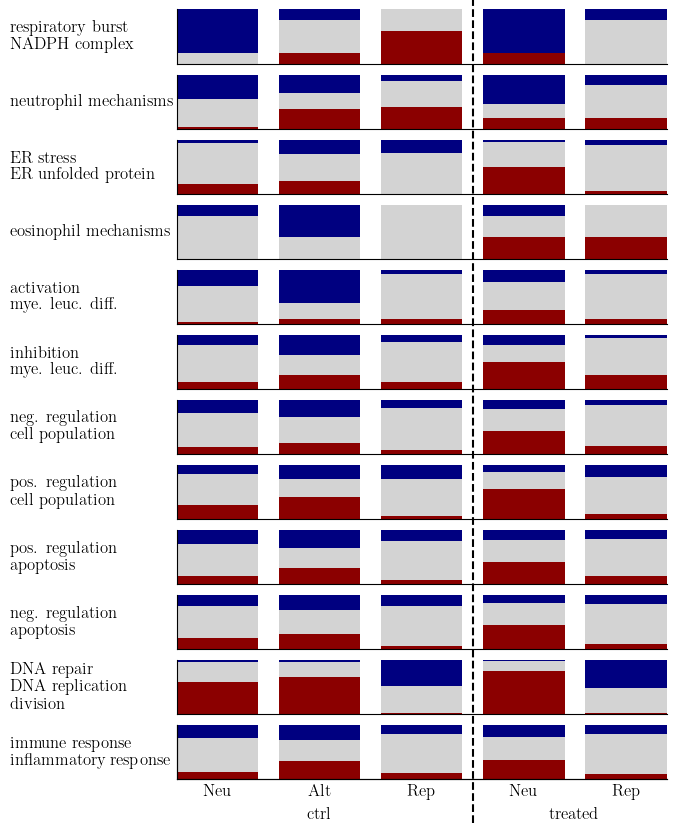

In [95]:
terminal_groups = [
    ("ctrl", "Neu"),
    ("ctrl", "Alt"),
    ("ctrl", "Rep"),
    ("treated", "Neu"),
    ("treated", "Rep"),
]

plot_marker_binarisation_grid(
    bin_macrostates,
    markers=markers,
    groups=terminal_groups,
    figsize=(7, 10),
    label_fontsize=12,
    tick_label_fontsize=12,
    label_x=-0.34,
    left_margin=0.2,
)
plt.savefig(FIGURE_DIR / "markers_extended.pdf")
plt.show()
plt.close()


### Paper-focused process panel <a class="anchor" id="fig-markers-paper"></a>

For the paper figure, the diagnostic is reduced to three process groups: proliferation-associated processes, neutrophil mechanisms, and inflammatory/immune response. This mirrors the main biological contrast discussed in the APL case study.


gene_set,n_genes
DNA repair/DNA replication/cell division,74
neutrophil/mechanisms,33
inflammatory/immune resp.,32


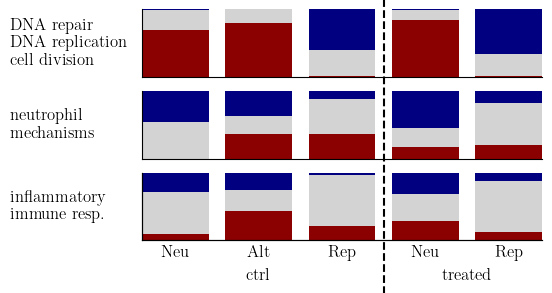

In [98]:
go_terms = {
    "DNA repair/DNA replication/cell division": ["GO:0006281", "GO:0006260", "GO:0051301"],
    "neutrophil/mechanisms": ["GO:0030593", "GO:0043315", "GO:0002446", "GO:0042119"],
    "inflammatory/immune resp.": ["GO:0050778", "GO:0050729"],
}

markers = dict()
for process_name, go_ids in go_terms.items():
    markers[process_name] = list(get_genes_from_go(go_ids, go2gene, go_dag, depth=0))

marker_summary = display_counts(
    {name: len(genes) for name, genes in markers.items()},
    index_name="gene_set",
    count_name="n_genes",
)

terminal_groups = [
    ("ctrl", "Neu"),
    ("ctrl", "Alt"),
    ("ctrl", "Rep"),
    ("treated", "Neu"),
    ("treated", "Rep"),
]

plot_marker_binarisation_grid(
    bin_macrostates,
    markers=markers,
    groups=terminal_groups,
    figsize=(5, 3),
    label_fontsize=12,
    tick_label_fontsize=12,
    label_x=-0.33,
    left_margin=0.1,
)
plt.savefig(FIGURE_DIR / "markers.pdf", bbox_inches="tight")
plt.show()
plt.close()


## Boolean networks <a class="anchor" id="bn"></a>

The remaining cells inspect Boolean-network inputs and outputs derived from the macrostate abstraction. The sections above provide the biological evidence used to define the states, terminal behaviours, and reachability assumptions.


In [36]:
import mpbn

def get_states(
    file,
    init_state_names=None,
    final_state_names=None,
    keys=None,
):
    """
    Load macrostate-associated Boolean states and selected hypercubes.

    Parameters
    ----------
    file: str
        CSV file containing genes in rows and state names in columns.
    init_state_names: list, optional
        State names to convert into initial-state hypercubes.
    final_state_names: list, optional
        State names to convert into terminal-state hypercubes.
    keys: list, optional
        Optional subset of row names to keep.

    Returns
    -------
    tuple
        State dataframe, initial-state hypercubes, and terminal-state
        hypercubes.
    """

    states = pd.read_csv(file, index_col=0).replace("-", "_")
    if keys is not None:
        states.drop(index=set(states.index) - set(keys), inplace=True)
    init_states = {state_name: bt.bpy.Hypercube(states.loc[:, state_name].to_dict()) for state_name in init_state_names} if init_state_names is not None else None
    final_states = {state_name: bt.bpy.Hypercube(states.loc[:, state_name].to_dict()) for state_name in final_state_names} if final_state_names is not None else None
    return states, init_states, final_states

states_bin = {}
states_bin["states"] = pd.read_csv("data/interest/bin/bin_macrostates.csv", index_col=0).fillna("*").replace("-", "_").transpose()

bn_one = mpbn.MPBooleanNetwork.load("data/interest/bn/one/one.bnet")
states_one = {}
states_one["states"], states_one["initial"], states_one["terminal"] = get_states(
    "data/interest/bn/one/metastates.csv",
    init_state_names=["ctrl_promyelocytes", "treated_promyelocytes"],
    final_state_names=["ctrl_proliferation", "ctrl_apoptosis", "ctrl_differentiation", "treated_proliferation", "treated_differentiation"]
)

components = set(states_one["states"].index)
components_in_bin_and_bn = components.intersection(set(states_bin["states"].index))
components_in_bn_notin_bin = components.difference(set(states_bin["states"].index))

component_summary = display_counts(
    {
        "BN components": len(components),
        "components in macrostates and BN": len(components_in_bin_and_bn),
        "components in BN only": len(components_in_bn_notin_bin),
    },
    index_name="summary",
    count_name="n_components",
)

if components_in_bn_notin_bin:
    display(pd.Series(sorted(components_in_bn_notin_bin), name="components in BN only"))

states_bin["states"] = pd.concat([states_bin["states"], pd.DataFrame(data="*", index=list(components_in_bn_notin_bin), columns=states_bin["states"].columns)], axis=0)
states_bin["states"].rename(columns={
    "ctrl_Prom1": "ctrl_promyelocytes",
    "ctrl_Prom2": "ctrl_intermediary",
    "ctrl_Rep": "ctrl_proliferation",
    "ctrl_Alt": "ctrl_altered",
    "ctrl_Neu": "ctrl_differentiation",
    "treated_Prom1": "treated_promyelocytes",
    "treated_Prom2": "treated_intermediary",
    "treated_Rep": "treated_proliferation",
    "treated_Neu": "treated_differentiation",
}, inplace=True)
states_bin["states"] = states_bin["states"].loc[states_one["states"].index, states_one["states"].columns]
states_bin["initial"] = {state_name: bt.bpy.Hypercube(states_bin["states"].loc[:,state_name].to_dict()) for state_name in ["ctrl_promyelocytes", "treated_promyelocytes"]}
states_bin["terminal"] = {state_name: bt.bpy.Hypercube(states_bin["states"].loc[:,state_name].to_dict()) for state_name in ["ctrl_proliferation", "ctrl_apoptosis", "ctrl_differentiation", "treated_proliferation", "treated_differentiation"]}

display(states_one["states"].transpose())
display(states_bin["states"].transpose())

Number of components: 127
Number of components in both macrostates and BN: 114
Number of components in BN not in macrostates: 13
Components in BN not in macrostates: {'Pgr', 'Atf3', 'Irf4', 'Wt1', 'Pou5f1', 'Egr1', 'Nanog', 'Rora', 'Ar', 'Snai2', 'Mycn', 'Gata4', 'Gata3'}


KeyError: "None of [Index(['ctrl_promyelocytes', 'ctrl_intermediary', 'ctrl_proliferation',\n       'ctrl_apoptosis', 'ctrl_differentiation', 'treated_promyelocytes',\n       'treated_intermediary', 'treated_proliferation',\n       'treated_differentiation'],\n      dtype='object')] are in the [columns]"

In [11]:
attractors = bt.bpy.HypercubeCollection(list(bn_one.attractors()))
attractor_summary = display_counts(
    {
        "attractors": len(attractors),
        "fixed points": len(attractors.get_fixed_points()),
    },
    index_name="summary",
    count_name="n",
)

display(pd.DataFrame.from_dict(attractors))

Number of attractors: 5
Number of fixed points: 5
Attractors:


,Apaf1,Apex1,Aph1a,Apobr,Ar,Asf1b,Atf3,Atp1a3,Aurka,B4galt1,Birc5,Bnip3l,Bphl,Car9,Ccna2,Ccnb1,Ccnb2,Ccnd2,Ccne1,Cd1d1,Cdc25a,Cdc25b,Cdc45,Cdc6,Cdk1,Cdk4,Cdkn1a,Cdkn2c,Cdt1,Ceacam1,Cebpa,Cebpb,Cebpd,Ckm,Csf2,Ctcf,Cxcl10,Dbf4,Dhfr,Dpy30,E2f1,E2f2,E2f7,Egr1,Ehhadh,Esr1,Ets1,Exosc8,Ezh2,Gadd45a,Gata1,Gata3,Gata4,Gfi1,Gmnn,Gnl3,H2-Q10,Hbp1,Hells,Hif1a,Hmgcr,Hsd17b1,Hspa9,Hspd1,Hspe1,Ifngr1,Il12a,Irf4,Jun,Kif23,Kif2c,Ldlr,Macrod1,Map4,Mat2a,Mcm5,Mcm6,Mcm7,Mst1,Mthfd1,Mycn,Nanog,Ncf1,Ncoa3,Ndrg1,Nfkb1,Nol3,Nol7,Nr3c1,Pcna,Pdgfrb,Pgr,Plk1,Pml,Pola1,Pold1,Pou5f1,Ptgds,Pttg1,Racgap1,Rela,Rhob,Rora,Rrm2,Rxra,Serpina3d-ps,Smad3,Smad7,Snai2,Sod1,Sp1,Sp3,Srms,Tff3,Tfrc,Tk1,Tnfaip8l1,Top2a,Trp53,Tyms,Ube2c,Vcam1,Wrn,Wt1,Ybx3,Zeb1,Zfp462
0,1,1,0,1,0,1,0,1,0,1,1,1,0,0,0,0,0,1,1,0,1,0,1,1,1,1,1,1,1,1,0,1,0,0,1,0,0,0,1,1,1,1,0,1,0,1,0,1,1,1,1,0,0,0,1,1,1,0,1,0,0,1,1,1,1,0,0,1,1,0,0,0,0,1,1,1,1,1,0,1,0,1,1,0,1,1,1,0,1,1,0,1,0,0,1,1,0,0,0,0,0,0,0,1,0,1,1,0,1,0,1,1,1,0,1,1,0,1,0,1,0,0,1,1,1,1,0
1,1,1,0,1,0,1,0,1,0,1,1,1,0,0,0,0,0,0,1,0,1,0,1,1,1,1,1,1,1,1,0,1,0,0,0,0,0,0,1,1,1,1,0,1,0,0,1,1,1,1,0,0,0,0,1,1,1,0,1,0,0,1,1,1,1,0,0,1,0,0,0,0,0,1,1,1,1,1,0,1,0,1,1,0,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,1,1,0,1,1,0,1,0,1,0,0,1,0,1,1,0
2,0,0,0,1,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,1,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0
3,0,0,0,1,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,1,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
4,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0


### 2. Pairwise macrostate distances <a class="anchor" id="distances"></a>

In [8]:
from itertools import combinations

pd.set_option("display.width", 100)

def get_distance(df, s1, s2):
    """
    Count mismatching binarised genes between two macrostates.

    Parameters
    ----------
    df: DataFrame
        Macrostate-by-gene matrix with NaN for undefined values.
    s1: str
        First macrostate name.
    s2: str
        Second macrostate name.

    Returns
    -------
    int
        Number of genes defined in both macrostates with different values.
    """

    distance = 0
    for gene in df.columns:
        if (not np.isnan(df.loc[s1, gene])) and (not np.isnan(df.loc[s2, gene])):
            if df.loc[s1, gene] != df.loc[s2, gene]:
                distance += 1
    return distance

def get_maximum(df, s1, s2):
    """
    Count jointly defined genes between two macrostates.

    Parameters
    ----------
    df: DataFrame
        Macrostate-by-gene matrix with NaN for undefined values.
    s1: str
        First macrostate name.
    s2: str
        Second macrostate name.

    Returns
    -------
    int
        Maximum observable distance, i.e. the number of genes defined in both
        macrostates.
    """

    maximum = 0
    for gene in df.columns:
        if (not np.isnan(df.loc[s1, gene])) and (not np.isnan(df.loc[s2, gene])):
            maximum += 1
    return maximum

index = ["ctrl_promyelocytes", "ctrl_proliferation", "ctrl_differentiation", "ctrl_apoptosis", "treated_promyelocytes", "treated_proliferation", "treated_differentiation"]
macrostates = states_bin["states"].transpose().replace("*", float("nan"))

distance = pd.DataFrame(index=index, columns=index)
for s1, s2 in combinations(index, 2):
    distance.at[s1, s2] = get_distance(macrostates, s1, s2)
for s in index:
    distance.at[s, s] = get_distance(macrostates, s, s)

maximum = pd.DataFrame(index=index, columns=index)
for s1, s2 in combinations(index, 2):
    maximum.at[s1, s2] = get_maximum(macrostates, s1, s2)
for s in index:
    maximum.at[s, s] = get_maximum(macrostates, s, s)

display(distance.style.set_caption("Pairwise macrostate distances"))
display(maximum.style.set_caption("Jointly binarised genes per macrostate pair"))

Distance:


,ctrl_promyelocytes,ctrl_proliferation,ctrl_differentiation,ctrl_apoptosis,treated_promyelocytes,treated_proliferation,treated_differentiation
ctrl_promyelocytes,0,6,37,36,4,8,44
ctrl_proliferation,NaN,0,32,34,8,1,37
ctrl_differentiation,NaN,NaN,0,1,27,37,1
ctrl_apoptosis,NaN,NaN,NaN,0,34,40,5
treated_promyelocytes,NaN,NaN,NaN,NaN,0,5,31
treated_proliferation,NaN,NaN,NaN,NaN,NaN,0,40
treated_differentiation,NaN,NaN,NaN,NaN,NaN,NaN,0


Maximum:


,ctrl_promyelocytes,ctrl_proliferation,ctrl_differentiation,ctrl_apoptosis,treated_promyelocytes,treated_proliferation,treated_differentiation
ctrl_promyelocytes,53,27,39,45,23,26,49
ctrl_proliferation,NaN,46,37,44,21,37,43
ctrl_differentiation,NaN,NaN,64,59,29,42,61
ctrl_apoptosis,NaN,NaN,NaN,82,37,46,75
treated_promyelocytes,NaN,NaN,NaN,NaN,41,22,38
treated_proliferation,NaN,NaN,NaN,NaN,NaN,51,48
treated_differentiation,NaN,NaN,NaN,NaN,NaN,NaN,92


Pairwise distance matrix between macrostates based on the selected genes. Each pairwise distance corresponds to the number of genes that are binarised in both macrostates but with different values. The number in parentheses below indicates the maximum potential distance, i.e. the number of genes binarised in both macrostates. The pairwise similarity matrix can be obtained by subtracting the distance from the maximum potential distance.
- promyelocytes and proliferative cells are quite similar, independently of the condition
- granulocytes and apoptotic cells are quite similar, independently of the condition
- granulocytes and proliferatives cells show high differences
- some differences are higher between conditions than between macrostates, highlighting the effect of treatment

### 3. Subset minimal BNs <a class="anchor" id="minimal"></a>

number of configurations associated to macrostate ctrl_apo: 2^45 = 35184372088832
number of configurations associated to macrostate ctrl_gran2: 2^63 = 9223372036854775808
number of configurations associated to macrostate ctrl_prom1: 2^74 = 18889465931478580854784
number of configurations associated to macrostate ctrl_prom2: 2^61 = 2305843009213693952
number of configurations associated to macrostate ctrl_rep: 2^81 = 2417851639229258349412352
number of configurations associated to macrostate treated_apo: 2^102 = 5070602400912917605986812821504
number of configurations associated to macrostate treated_gran2: 2^35 = 34359738368
number of configurations associated to macrostate treated_prom1: 2^86 = 77371252455336267181195264
number of configurations associated to macrostate treated_prom2: 2^92 = 4951760157141521099596496896
number of configurations associated to macrostate treated_rep: 2^76 = 75557863725914323419136


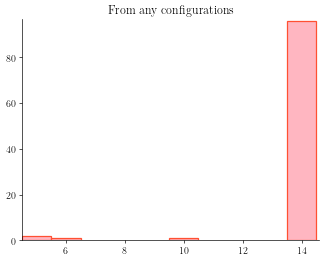

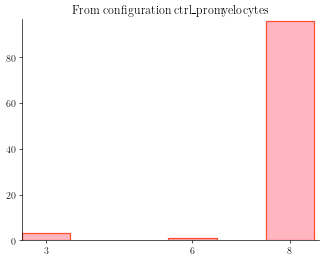

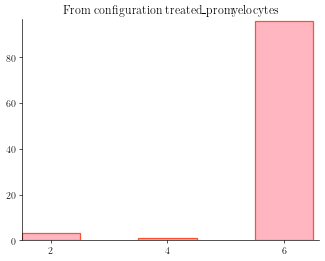

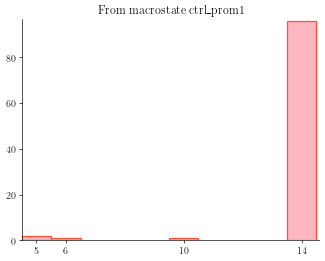

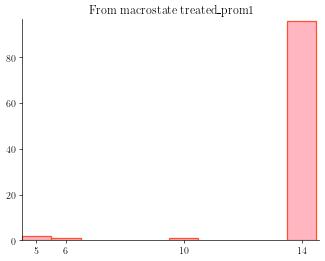

In [32]:
import math

import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 60

bns = []
cfgs = []

macrostates = pd.read_csv("data/interest/bin/bin_macrostates.csv", index_col=0).transpose()
for c in set(components) - set(macrostates.index):
    macrostates.loc[c] = pd.Series()
macrostates = macrostates.loc[components,:].replace(math.nan, "*").to_dict()
for k, v in macrostates.items():
    macrostates[k] = bt.bpy.Hypercube(v)

configuration_space = dict()
for condition, macrostate in macrostates.items():
    to_remove = []
    for k, v in macrostate.items():
        if isinstance(v, str):
            to_remove.append(k)

    configuration_space[condition] = {
        "n_free_components": len(to_remove),
        "n_configurations": 2 ** len(to_remove),
    }
    for k in to_remove:
        del macrostate[k]

configuration_space = pd.DataFrame.from_dict(configuration_space, orient="index")
configuration_space.index.name = "macrostate"
display(configuration_space)

for i in range(100):
    bns.append(mpbn.MPBooleanNetwork.load(f"data/interest/bn/sub/{i}/sub.bnet"))
    cfg = pd.read_csv(f"data/interest/bn/sub/{i}/metastates.csv", index_col=0).to_dict()
    for k, v in cfg.items():
        cfg[k] = bt.bpy.Hypercube(v)
    cfgs.append(cfg)
    del cfg

bns = bt.bpy.BooleanNetworkEnsemble(bns=bns)
components = list(bns.get_components())

attractor_number = pd.Series([len(list(bn.attractors())) for bn in bns]).value_counts().to_dict()
k, v = [], []
for n in sorted(attractor_number.keys()):
    k.append(n)
    v.append(attractor_number[n])
fig, ax = plt.subplots(nrows=1, ncols=1)
plt.bar(k, v, width=1, facecolor=bt.sct.pl.get_color("pink"), edgecolor=bt.sct.pl.get_color("red"), linewidth=1.5)
plt.xlim([k[0]-0.5, k[-1]+0.6])
plt.ylim(0, max(v)+1)
plt.title("From any configurations")
plt.show()
plt.close()

for name in ["ctrl_promyelocytes", "treated_promyelocytes"]:
    attractor_number = pd.Series([len(list(bn.attractors(reachable_from=cfg[name]))) for cfg, bn in zip(cfgs, bns)]).value_counts().to_dict()
    k, v = [], []
    for n in sorted(attractor_number.keys()):
        k.append(n)
        v.append(attractor_number[n])
    fig, ax = plt.subplots(nrows=1, ncols=1)
    plt.bar(k, v, width=1, facecolor=bt.sct.pl.get_color("pink"), edgecolor=bt.sct.pl.get_color("red"), linewidth=1.5)
    plt.xlim([k[0]-0.5, k[-1]+0.6])
    plt.ylim(0, max(v)+1)
    plt.xticks(k)
    plt.title(f"From configuration {name}")
    plt.show()
    plt.close()

for name in ["ctrl_prom1", "treated_prom1"]:
    attractor_number = pd.Series([len(list(bn.attractors(reachable_from=macrostates[name]))) for bn in bns]).value_counts().to_dict()
    k, v = [], []
    for n in sorted(attractor_number.keys()):
        k.append(n)
        v.append(attractor_number[n])
    fig, ax = plt.subplots(nrows=1, ncols=1)
    plt.bar(k, v, width=1, facecolor=bt.sct.pl.get_color("pink"), edgecolor=bt.sct.pl.get_color("red"), linewidth=1.5)
    plt.xlim([k[0]-0.5, k[-1]+0.6])
    plt.ylim(0, max(v)+1)
    plt.xticks(k)
    plt.title(f"From macrostate {name}")
    plt.show()
    plt.close()

In [35]:
macrostate_size_summary = display_counts(
    {name: len(macrostate) for name, macrostate in macrostates.items()},
    index_name="macrostate",
    count_name="n_defined_components",
)


ctrl_apo 82
ctrl_gran2 64
ctrl_prom1 53
ctrl_prom2 66
ctrl_rep 46
treated_apo 25
treated_gran2 92
treated_prom1 41
treated_prom2 35
treated_rep 51
